<a href="https://colab.research.google.com/github/ThiagoBrandaorj/Machine_learning/blob/main/C%C3%B3pia_de_01_Evas%C3%A3o_banc%C3%A1ria.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **DESAFIO 01 - EVASÃO BANCÁRIA (CHURN)**

Vamos usar [este conjunto de dados](https://github.com/cassiusf/datasets/raw/refs/heads/main/desafios/Churn_Dataset.csv) para tentar prever evasão de clientes no setor bancário.

Este conjunto de dados contém informações sobre clientes bancários que deixaram o banco ou continuam sendo seus clientes. O conjunto de dados inclui as seguintes variáveis:

- **Customer ID**: identificador único para cada cliente
- **Surname**: sobrenome do cliente
- **Credit Score**: valor numérico representando o score de crédito do cliente, ou seja, uma classificação interna do quão bom pagador ele é
- **Geography**: país onde o cliente reside (França, Espanha ou Alemanha)
- **Gender**: gênero do cliente (masculino ou feminino)
- **Age**: idade do cliente.
- **Tenure**: número de anos que o cliente está no banco.
- **Balance**: saldo da conta do cliente.
- **NumOfProducts**: número de produtos bancários utilizados pelo cliente (por exemplo, conta poupança, cartão de crédito).
- **HasCrCard**: se o cliente tem um cartão de crédito (1 = sim, 0 = não).
- **IsActiveMember**: se o cliente é um membro ativo (1 = sim, 0 = não).
- **EstimatedSalary**: renda estimada do cliente.
- **Exited**: evasão do cliente (1 = sim, 0 = não) ***(Variável alvo)***.


## **TAREFA**

Seu objetivo é utilizar um modelo de machine learning rasa para prever a possibilidade de um cliente cancelar sua conta no banco.

Você deverá fazer todas es etapas necessárias tanto na avaliação dos dados disponíveis quanto na preparação necessária para execução do modelo escolhido.

Todas estas etapas devem ser documentadas e as escolhas justificadas. Não esqueça de indicar claramente suas referências.

A performance do seu modelo deverá ser avaliada pelas métricas Acurácia, Precision, Recall e F1-Score. Inclua em sua avaliação final de performance Curvas, ROC e/ou Precision-Recall, de acordo com a necessidade.

Iniciem hoje em sala e apresentem seus resultados em formato de apresentação técnica com slides na aula da semana que vem, dia 05/03/2026.

## 1 - EDA

In [ ]:
!pip install -q imbalanced-learn shap

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
import random
import sys
import platform
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Reprodutibilidade
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

def show_versions():
    import sklearn, scipy
    vers = {
        "python": sys.version.split()[0],
        "platform": platform.platform(),
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "scipy": scipy.__version__,
        "sklearn": sklearn.__version__,
    }
    try:
        import imblearn
        vers["imblearn"] = imblearn.__version__
    except Exception:
        vers["imblearn"] = "not installed"
    try:
        import shap
        vers["shap"] = shap.__version__
    except Exception:
        vers["shap"] = "not installed"
    return vers

VERSIONS = show_versions()
VERSIONS


{'python': '3.12.12',
 'platform': 'Linux-6.6.113+-x86_64-with-glibc2.35',
 'numpy': '2.0.2',
 'pandas': '2.2.2',
 'scipy': '1.16.3',
 'sklearn': '1.6.1',
 'imblearn': '0.14.1',
 'shap': '0.51.0'}

In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/cassiusf/datasets/refs/heads/main/desafios/Churn_Dataset.csv")
df.head(100)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42.0,2,0.00,1,1.0,1.0,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41.0,1,83807.86,1,0.0,1.0,112542.58,0
2,3,15619304,Onio,502,France,Female,42.0,8,159660.80,3,1.0,0.0,113931.57,1
3,4,15701354,Boni,699,France,Female,39.0,1,0.00,2,0.0,0.0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43.0,2,125510.82,1,NaN,1.0,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,15699461,Fiorentini,515,Spain,Male,35.0,10,176273.95,1,0.0,1.0,121277.78,0
96,97,15738721,Graham,773,Spain,Male,41.0,9,102827.44,1,0.0,1.0,64595.25,0
97,98,15693683,Yuille,814,Germany,Male,29.0,8,97086.40,2,1.0,1.0,197276.13,0
98,99,15604348,Allard,710,Spain,Male,22.0,8,0.00,2,0.0,0.0,99645.04,0


In [ ]:
df.shape

(10002, 14)

In [ ]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [ ]:
df.dtypes

,0
RowNumber,int64
CustomerId,int64
Surname,object
CreditScore,int64
Geography,object
Gender,object
Age,float64
Tenure,int64
Balance,float64
NumOfProducts,int64


In [ ]:
# Verificar se há duplicatas
df.duplicated().sum()

np.int64(2)

**Existem 2 linhas duplicadas**

In [ ]:
df[df.duplicated(keep=False)]

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
9998,9999,15682355,Sabbatini,772,Germany,Male,42.0,3,75075.31,2,1.0,0.0,92888.52,1
9999,9999,15682355,Sabbatini,772,Germany,Male,42.0,3,75075.31,2,1.0,0.0,92888.52,1
10000,10000,15628319,Walker,792,France,Female,28.0,4,130142.79,1,1.0,0.0,38190.78,0
10001,10000,15628319,Walker,792,France,Female,28.0,4,130142.79,1,1.0,0.0,38190.78,0


In [ ]:
# remover as 2 linhas duplicadas
df = df.drop_duplicates()

In [ ]:
df.shape

(10000, 14)

In [ ]:
# Ver o total de NAs em cada coluna
print(df.isna().sum())

# Ver quantas linhas têm pelo menos um NA
print(f"Linhas com NA: {df.isna().any(axis=0).sum()}")

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          1
Gender             0
Age                1
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          1
IsActiveMember     1
EstimatedSalary    0
Exited             0
dtype: int64
Linhas com NA: 4


**Temos apenas 4 registros com NA, em uma base de 10 mil registros remover esses registros não vai resultar em nada**

In [ ]:
df[df.isna().any(axis=1)]

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
4,5,15737888,Mitchell,850,Spain,Female,43.0,2,125510.82,1,NaN,1.0,79084.10,0
6,7,15592531,Bartlett,822,NaN,Male,50.0,7,0.00,2,1.0,1.0,10062.80,0
8,9,15792365,He,501,France,Male,44.0,4,142051.07,2,0.0,NaN,74940.50,0
9,10,15592389,H?,684,France,Male,NaN,2,134603.88,1,1.0,1.0,71725.73,0


In [ ]:
df = df.dropna()

In [ ]:
df.shape

(9996, 14)

In [ ]:
df['CustomerId'].nunique()

9996

**Podemos ver que a variável CustomerID é apenas um ID de cada cliente desse banco, portanto também iremos excluir, pois ela não terá nenhuma utilidade na predição**

In [ ]:
# Excluir as variáveis RowNumber, CustomerId, pois não são úteis para o modelo.
df = df.drop(['RowNumber', 'CustomerId'], axis=1)
df.head()

,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,Hargrave,619,France,Female,42.0,2,0.00,1,1.0,1.0,101348.88,1
1,Hill,608,Spain,Female,41.0,1,83807.86,1,0.0,1.0,112542.58,0
2,Onio,502,France,Female,42.0,8,159660.80,3,1.0,0.0,113931.57,1
3,Boni,699,France,Female,39.0,1,0.00,2,0.0,0.0,93826.63,0
5,Chu,645,Spain,Male,44.0,8,113755.78,2,1.0,0.0,149756.71,1


In [ ]:
df['Surname'].nunique()

2932

**A variável de Surname possui uma cardinalidade altíssima, quase 3 mil classes, porém vale a pena analisar se a mesma pode ou nao ter utilidade na predição(mais a frente em uma ánalise mais profunda optamos por exclui-lá)**

## Verificação de Clusters

['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']


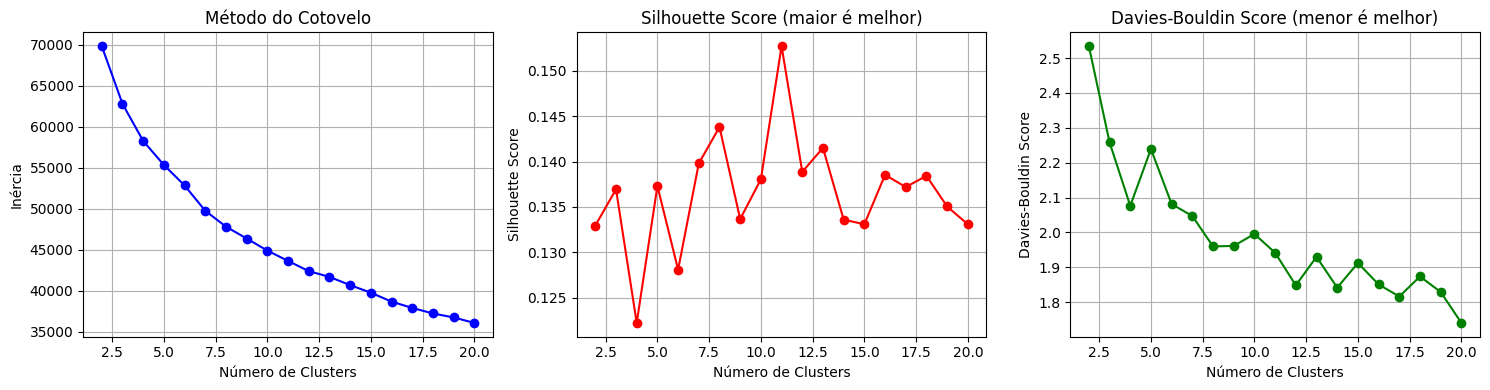


📊 Número de clusters recomendado:
   - Por Silhouette Score: 11
   - Por Davies-Bouldin: 20


In [ ]:
# Função para preparar dados para clusterização
def prepare_for_clustering(df, exclude_cols=['Exited']):
    cols_to_use = [col for col in df.select_dtypes(include=[np.number]).columns
                   if col not in exclude_cols]
    print(cols_to_use)
    return df[cols_to_use]

# Preparar dados
X_cluster = prepare_for_clustering(df)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Função para avaliar número ideal de clusters
def evaluate_clusters(X, max_clusters=20):
    """Avalia diferentes métricas para encontrar número ideal de clusters"""

    inertias = []
    sil_scores = []
    db_scores = []
    models = []

    for k in range(2, max_clusters + 1):
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(X)

        inertias.append(kmeans.inertia_)
        sil_scores.append(silhouette_score(X, labels))
        db_scores.append(davies_bouldin_score(X, labels))
        models.append(kmeans)

    # Visualização
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Método do cotovelo
    axes[0].plot(range(2, max_clusters + 1), inertias, 'bo-')
    axes[0].set_xlabel('Número de Clusters')
    axes[0].set_ylabel('Inércia')
    axes[0].set_title('Método do Cotovelo')
    axes[0].grid(True)

    # Silhouette Score
    axes[1].plot(range(2, max_clusters + 1), sil_scores, 'ro-')
    axes[1].set_xlabel('Número de Clusters')
    axes[1].set_ylabel('Silhouette Score')
    axes[1].set_title('Silhouette Score (maior é melhor)')
    axes[1].grid(True)

    # Davies-Bouldin Score
    axes[2].plot(range(2, max_clusters + 1), db_scores, 'go-')
    axes[2].set_xlabel('Número de Clusters')
    axes[2].set_ylabel('Davies-Bouldin Score')
    axes[2].set_title('Davies-Bouldin Score (menor é melhor)')
    axes[2].grid(True)

    plt.tight_layout()
    plt.show()

    # Recomendação
    best_k_sil = range(2, max_clusters + 1)[np.argmax(sil_scores)]
    best_k_db = range(2, max_clusters + 1)[np.argmin(db_scores)]

    print(f"\n📊 Número de clusters recomendado:")
    print(f"   - Por Silhouette Score: {best_k_sil}")
    print(f"   - Por Davies-Bouldin: {best_k_db}")

    return models, inertias, sil_scores, db_scores

# Avaliar clusters
models, inertias, sil_scores, db_scores = evaluate_clusters(X_scaled, max_clusters=20)


🔍 Usando 2 clusters para análise


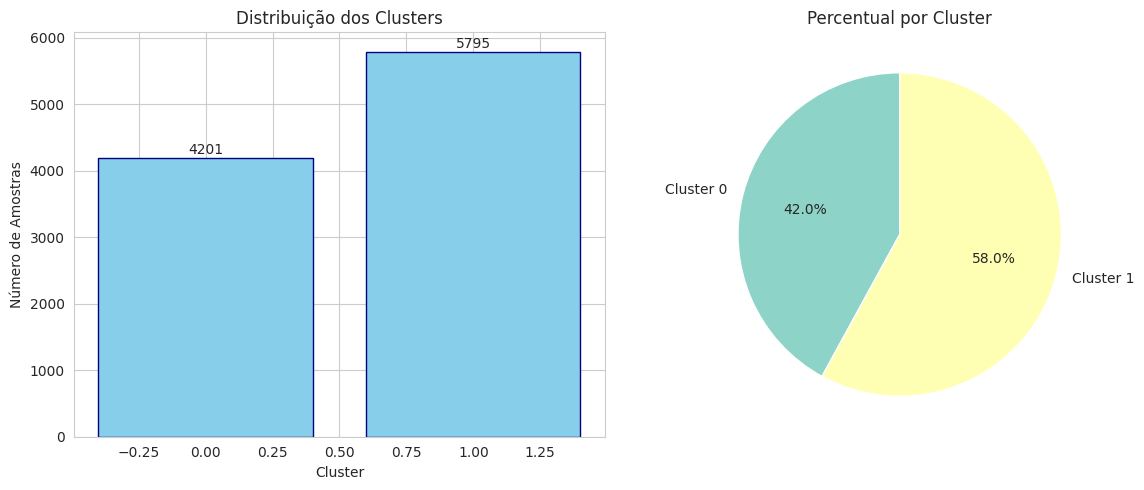


📊 Visualizando relações entre variáveis principais:


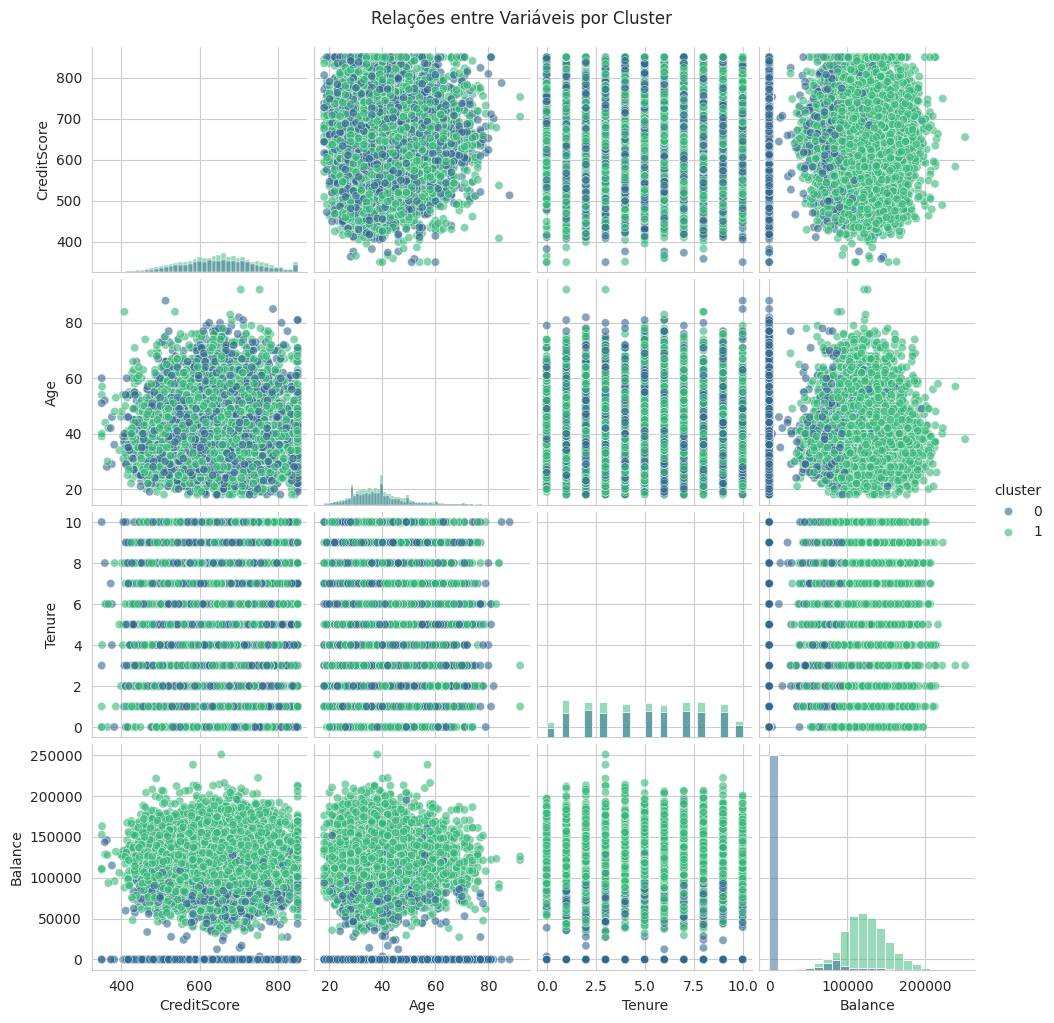

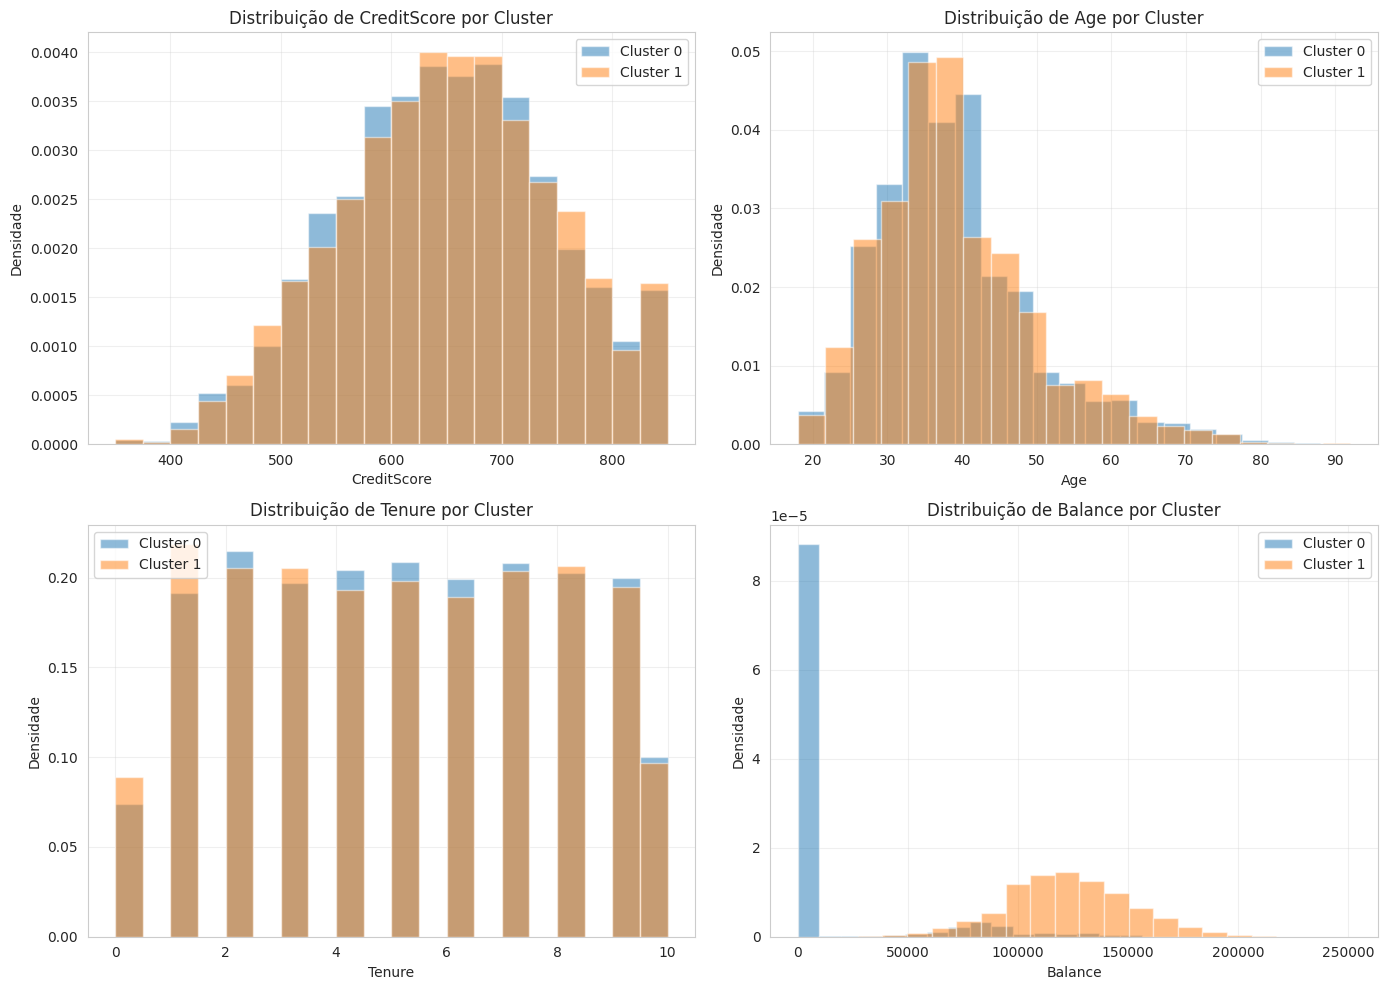

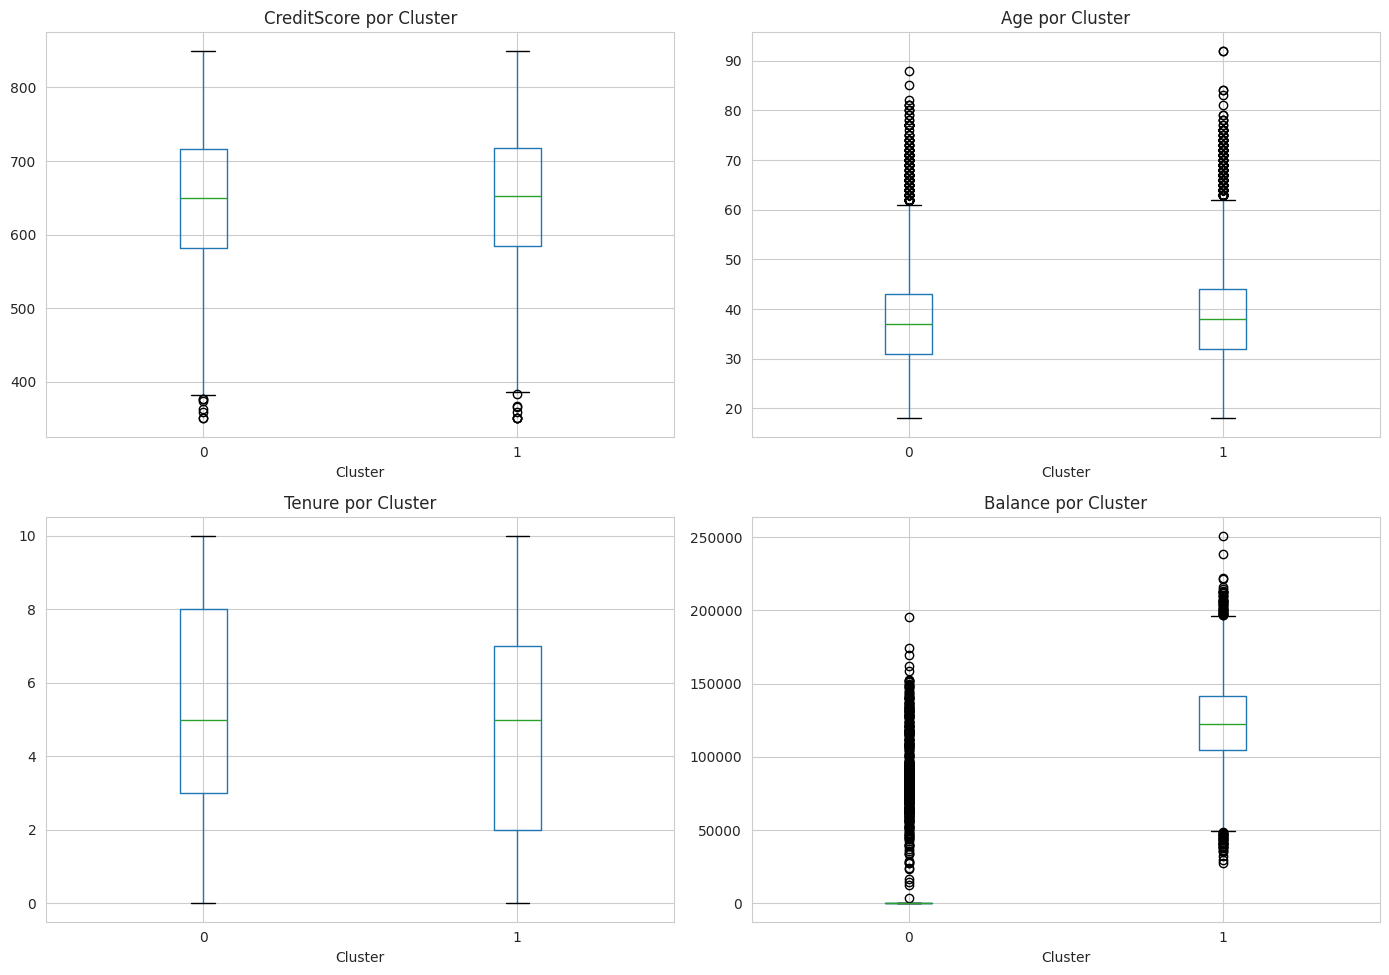

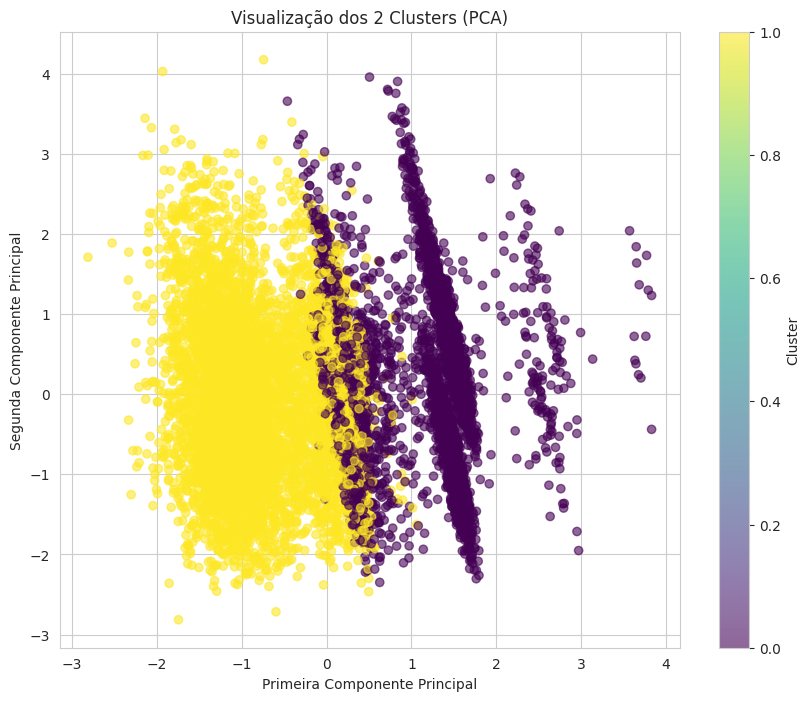


📈 Estatísticas Descritivas por Cluster:


CreditScore                     Age                    Tenure        \
               mean    std  min  max   mean    std   min   max   mean   std   
cluster                                                                       
0            649.27  96.48  350  850  38.65  10.52  18.0  88.0   5.07  2.86   
1            651.40  96.73  350  850  39.12  10.46  18.0  92.0   4.97  2.91   

         ... IsActiveMember      EstimatedSalary                              \
         ...            min  max            mean       std    min        max   
cluster  ...                                                                   
0        ...            0.0  1.0        99226.46  57677.73  90.07  199992.48   
1        ...            0.0  1.0       100744.82  57390.37  11.58  199970.74   

        Exited                
          mean   std min max  
cluster                       
0         0.17  0.38   0   1  
1         0.23  0.42   0   1  

[2 rows x 36 columns]


🎯 Taxa de Churn (Exited) por Cluster:


,Taxa de Churn (%),Total Clientes
cluster,,
0,17.42,4201
1,22.52,5795


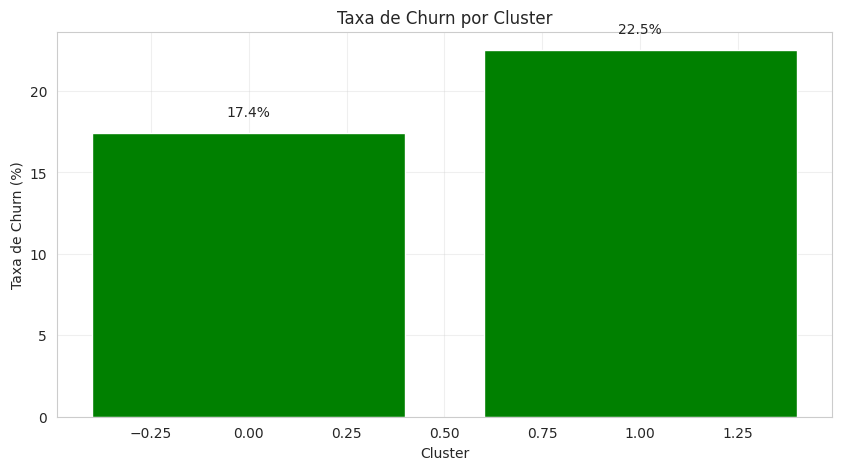

In [ ]:
# Escolher o número de clusters (vamos usar o sugerido pelo Silhouette Score)
n_clusters = 2  # ou escolha manualmente
print(f"\n🔍 Usando {n_clusters} clusters para análise")

# Aplicar K-means final
kmeans_final = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_scaled)

# Adicionar labels ao dataset original
df_with_clusters = df.copy()
df_with_clusters['cluster'] = cluster_labels

# NOVA FUNÇÃO: Visualizar distribuição dos clusters no dataset original
def plot_cluster_distribution(df, cluster_col='cluster'):
    """
    Visualiza a distribuição dos clusters em várias dimensões do dataset original
    """
    import seaborn as sns

    # Configurar o estilo dos gráficos
    sns.set_style("whitegrid")

    # 1. GRÁFICO DE BARRAS - Distribuição dos clusters
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    cluster_counts = df[cluster_col].value_counts().sort_index()
    bars = plt.bar(cluster_counts.index, cluster_counts.values, color='skyblue', edgecolor='navy')
    plt.xlabel('Cluster')
    plt.ylabel('Número de Amostras')
    plt.title('Distribuição dos Clusters')
    # Adicionar valores nas barras
    for bar, count in zip(bars, cluster_counts.values):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                f'{count}', ha='center', va='bottom')

    # 2. GRÁFICO DE PIZZA - Percentual
    plt.subplot(1, 2, 2)
    plt.pie(cluster_counts.values, labels=[f'Cluster {i}' for i in cluster_counts.index],
            autopct='%1.1f%%', startangle=90, colors=plt.cm.Set3(range(len(cluster_counts))))
    plt.title('Percentual por Cluster')

    plt.tight_layout()
    plt.show()

    # 3. PAIRPLOT - Visualizar relações entre variáveis originais por cluster
    # Selecionar algumas variáveis importantes para visualização (ajuste conforme seus dados)
    important_cols = df.select_dtypes(include=[np.number]).columns[:4]  # primeiras 4 numéricas
    if len(important_cols) > 0:
        print("\n📊 Visualizando relações entre variáveis principais:")
        # Adicionar cluster como hue
        plot_df = df[list(important_cols) + [cluster_col]].copy()

        # Pairplot com cores por cluster
        g = sns.pairplot(data=plot_df, hue=cluster_col, palette='viridis',
                        diag_kind='hist', plot_kws={'alpha': 0.6})
        g.fig.suptitle('Relações entre Variáveis por Cluster', y=1.02)
        plt.show()

    # 4. DISTRIBUIÇÃO DAS VARIÁVEIS PRINCIPAIS por cluster
    n_vars = min(4, len(important_cols))
    if n_vars > 0:
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        axes = axes.ravel()

        for idx, col in enumerate(important_cols[:n_vars]):
            for cluster in df[cluster_col].unique():
                data = df[df[cluster_col] == cluster][col]
                axes[idx].hist(data, bins=20, alpha=0.5, label=f'Cluster {cluster}',
                             density=True)
            axes[idx].set_xlabel(col)
            axes[idx].set_ylabel('Densidade')
            axes[idx].set_title(f'Distribuição de {col} por Cluster')
            axes[idx].legend()
            axes[idx].grid(True, alpha=0.3)

        # Esconder subplots vazios se necessário
        for idx in range(n_vars, 4):
            fig.delaxes(axes[idx])

        plt.tight_layout()
        plt.show()

    # 5. BOXPLOTS - Comparação de distribuições
    n_boxplots = min(4, len(important_cols))
    if n_boxplots > 0:
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        axes = axes.ravel()

        for idx, col in enumerate(important_cols[:n_boxplots]):
            df.boxplot(column=col, by=cluster_col, ax=axes[idx], grid=True)
            axes[idx].set_title(f'{col} por Cluster')
            axes[idx].set_xlabel('Cluster')

        # Esconder subplots vazios se necessário
        for idx in range(n_boxplots, 4):
            fig.delaxes(axes[idx])

        plt.suptitle('')  # Remove o título automático do boxplot
        plt.tight_layout()
        plt.show()

# Chamar a nova função de visualização
plot_cluster_distribution(df_with_clusters)

# Visualizar os clusters reduzidos com PCA (mantendo do código original)
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='viridis', alpha=0.6)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('Primeira Componente Principal')
plt.ylabel('Segunda Componente Principal')
plt.title(f'Visualização dos {n_clusters} Clusters (PCA)')
plt.show()

# BÔNUS: Tabela resumo com estatísticas por cluster
print("\n📈 Estatísticas Descritivas por Cluster:")
print("=" * 60)

# Selecionar colunas numéricas para resumo
numeric_cols = df_with_clusters.select_dtypes(include=[np.number]).columns
numeric_cols = [col for col in numeric_cols if col != 'cluster']

# Calcular estatísticas por cluster
cluster_summary = df_with_clusters.groupby('cluster')[numeric_cols].agg(['mean', 'std', 'min', 'max']).round(2)
display(cluster_summary)

# Se houver variável alvo 'Exited' ou similar
if 'Exited' in df_with_clusters.columns:
    print("\n🎯 Taxa de Churn (Exited) por Cluster:")
    churn_by_cluster = df_with_clusters.groupby('cluster')['Exited'].agg(['mean', 'count'])
    churn_by_cluster['mean'] = churn_by_cluster['mean'] * 100  # Converter para porcentagem
    churn_by_cluster.columns = ['Taxa de Churn (%)', 'Total Clientes']
    display(churn_by_cluster.round(2))

    # Gráfico de barras para taxa de churn
    plt.figure(figsize=(10, 5))
    plt.bar(churn_by_cluster.index, churn_by_cluster['Taxa de Churn (%)'],
            color=['green' if x < 30 else 'orange' if x < 50 else 'red'
                   for x in churn_by_cluster['Taxa de Churn (%)']])
    plt.xlabel('Cluster')
    plt.ylabel('Taxa de Churn (%)')
    plt.title('Taxa de Churn por Cluster')
    for i, (idx, row) in enumerate(churn_by_cluster.iterrows()):
        plt.text(i, row['Taxa de Churn (%)'] + 1, f"{row['Taxa de Churn (%)']:.1f}%",
                ha='center')
    plt.grid(True, alpha=0.3)
    plt.show()

In [ ]:
df = df_with_clusters
df.head()

,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,cluster
0,Hargrave,619,France,Female,42.0,2,0.00,1,1.0,1.0,101348.88,1,0
1,Hill,608,Spain,Female,41.0,1,83807.86,1,0.0,1.0,112542.58,0,1
2,Onio,502,France,Female,42.0,8,159660.80,3,1.0,0.0,113931.57,1,1
3,Boni,699,France,Female,39.0,1,0.00,2,0.0,0.0,93826.63,0,0
5,Chu,645,Spain,Male,44.0,8,113755.78,2,1.0,0.0,149756.71,1,1


In [ ]:
# Dividir o conjunto entre X e y
X = df.drop('Exited', axis=1)
y = df['Exited']

In [ ]:
# Dividindo os dados entre treino,teste
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2,stratify=df['cluster'], random_state=42
)
print(f"tamanho do conjunto de treino: {X_train.shape[0]}")
print(f"tamanho do conjunto de teste: {X_test.shape[0]}")
y_train.mean(), y_test.mean()

tamanho do conjunto de treino: 7996
tamanho do conjunto de teste: 2000


(np.float64(0.20485242621310656), np.float64(0.1995))

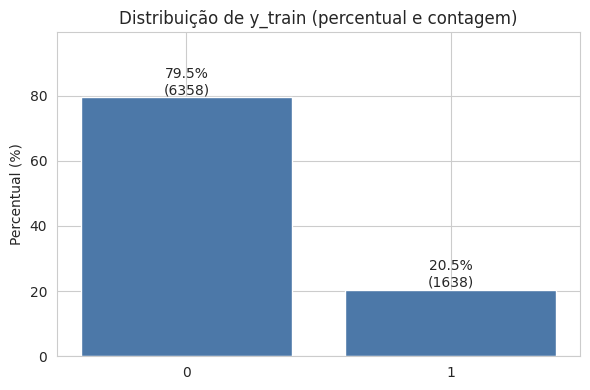

In [ ]:
# Verificar se estamos diante de um conjunto de dados desbalanceados ou não
import matplotlib.pyplot as plt

# Contagem absoluta e percentual
counts = y_train.value_counts().sort_index()
pct = y_train.value_counts(normalize=True).sort_index() * 100

plt.figure(figsize=(6,4))
bars = plt.bar(pct.index.astype(str), pct, color='#4C78A8')

# Adiciona rótulos com percentual + contagem
for bar, val_pct, val_cnt in zip(bars, pct, counts):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'{val_pct:.1f}%\n({val_cnt})',   # <-- AGORA TEM TAMBÉM A QUANTIDADE
        ha='center',
        va='bottom'
    )

plt.ylabel('Percentual (%)')
plt.title('Distribuição de y_train (percentual e contagem)')
plt.ylim(0, max(pct)*1.25)  # mais folga para caber 2 linhas de texto
plt.tight_layout()
plt.show()

**Estamos diante de um problema EXTREMAMENTE desbalanceados**

## CreditScore

<Axes: xlabel='CreditScore'>

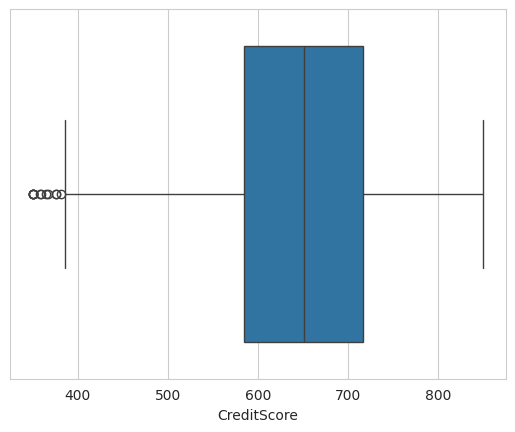

In [ ]:
# CreditScore (boxplot)
sns.boxplot(x=X_train['CreditScore'])

<Axes: >

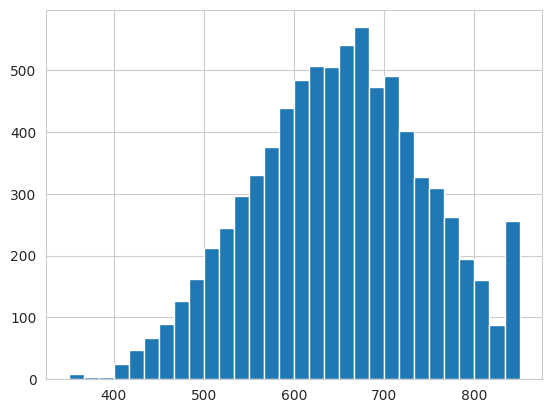

In [ ]:
# histograma para verificar formato dos dados
X_train['CreditScore'].hist(bins=30)

In [ ]:

col = 'CreditScore'
Q1 = X_train[col].quantile(0.25)
Q3 = X_train[col].quantile(0.75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Limite inferior:", limite_inferior)
print("Limite superior:", limite_superior)


Q1: 584.0
Q3: 716.25
IQR: 132.25
Limite inferior: 385.625
Limite superior: 914.625


In [ ]:
# verificar registros indicados como outliers pelo boxplot
X_train[(X_train['CreditScore'] < 384.5) | (X_train['CreditScore'] > 916.5)]

,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,cluster
2473,Chou,351,Germany,Female,57.0,4,163146.46,1,1.0,0.0,169621.69,1
8723,Onyekachi,350,France,Male,51.0,10,0.00,1,1.0,1.0,125823.79,0
8762,Lin,350,France,Female,60.0,3,0.00,1,0.0,0.0,113796.15,0
1962,Aikenhead,358,Spain,Female,52.0,8,143542.36,3,1.0,0.0,141959.11,0
942,Lin,376,France,Female,46.0,6,0.00,1,1.0,0.0,157333.69,0
1405,Panicucci,359,France,Female,44.0,6,128747.69,1,1.0,0.0,146955.71,1
1631,Azubuike,350,Spain,Male,54.0,1,152677.48,1,1.0,1.0,191973.49,1
9210,Watts,382,Spain,Male,36.0,0,0.00,1,1.0,1.0,179540.73,0
9624,Maslow,350,France,Female,40.0,0,111098.85,1,1.0,1.0,172321.21,1
7,Obinna,376,Germany,Female,29.0,4,115046.74,4,1.0,0.0,119346.88,0


**Aparentemente os Outliers são registros realmente válidos, portanto não iremos remover**

## Surname

In [ ]:
from IPython.display import display, HTML

# Criar DataFrame com todos os sobrenomes e suas frequências
surname_counts = X_train['Surname'].value_counts().reset_index()
surname_counts.columns = ['Sobrenome', 'Frequência']

# Adicionar colunas úteis
surname_counts['% do Total'] = (surname_counts['Frequência'] / surname_counts['Frequência'].sum() * 100).round(2)
surname_counts['% Acumulada'] = surname_counts['% do Total'].cumsum().round(2)
surname_counts['Rank'] = range(1, len(surname_counts) + 1)

# Reordenar colunas
surname_counts = surname_counts[['Rank', 'Sobrenome', 'Frequência', '% do Total', '% Acumulada']]

# Função para exibir tabela com rolagem
def display_scrollable_table(df, rows_per_page=50):
    """Exibe uma tabela com rolagem e paginação"""

    total_rows = len(df)
    total_pages = (total_rows + rows_per_page - 1) // rows_per_page

    # CSS para tabela com altura fixa e rolagem
    display(HTML("""
    <style>
        .scrollable-table {
            max-height: 600px;
            overflow-y: auto;
            border: 1px solid #ddd;
            border-radius: 5px;
            margin-bottom: 20px;
        }
        .scrollable-table table {
            border-collapse: collapse;
            width: 100%;
        }
        .scrollable-table th {
            position: sticky;
            top: 0;
            background-color: #4CAF50;
            color: white;
            padding: 12px;
            text-align: left;
            z-index: 1;
        }
        .scrollable-table td {
            padding: 8px 12px;
            border-bottom: 1px solid #ddd;
        }
        .scrollable-table tr:hover {
            background-color: #f5f5f5;
        }
        .pagination-info {
            margin-top: 10px;
            padding: 10px;
            background-color: #f0f0f0;
            border-radius: 5px;
            font-family: Arial, sans-serif;
        }
    </style>
    """))

    # Exibir informações de paginação
    display(HTML(f"""
    <div class="pagination-info">
        <strong>Total de sobrenomes:</strong> {total_rows} |
        <strong>Exibindo página 1 de {total_pages}</strong> |
        <strong>Mostrando {min(rows_per_page, total_rows)} sobrenomes por página</strong>
    </div>
    """))

    # Criar a tabela com rolagem
    html = '<div class="scrollable-table">'
    html += surname_counts.head(rows_per_page).to_html(index=False, escape=False)
    html += '</div>'

    display(HTML(html))

# Exibir tabela com rolagem
display_scrollable_table(surname_counts, rows_per_page=500)

Rank,Sobrenome,Frequência,% do Total,% Acumulada
1,Walker,25,0.31,0.31
2,Scott,25,0.31,0.62
3,Smith,24,0.30,0.92
4,Brown,23,0.29,1.21
5,Ma,22,0.28,1.49
6,Genovese,20,0.25,1.74
7,Yeh,20,0.25,1.99
8,Wilson,20,0.25,2.24
9,Shih,19,0.24,2.48
10,Trevisani,19,0.24,2.72


**Como muitos modelos não lidam bem com variáveis de alta cardinalidade, iremos como teste por enquanto excluir a variável 'Surname'**

In [ ]:
X_train = X_train.drop('Surname', axis=1)
X_train.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,cluster
2116,701,France,Male,44.0,7,0.00,2,1.0,0.0,23425.78,0
6526,574,France,Female,34.0,7,152992.91,1,1.0,1.0,134691.20,1
2016,696,France,Male,28.0,4,172646.82,1,1.0,1.0,116471.43,1
9820,648,Germany,Female,45.0,5,118886.55,1,0.0,0.0,51636.70,1
5421,589,France,Female,39.0,7,0.00,2,0.0,0.0,95985.64,0


## Geography

In [ ]:
X_train['Geography'].value_counts()

,count
Geography,
France,4002
Germany,2014
Spain,1980


**Nada de anormal nesta variável**

## Gender

In [ ]:
X_train['Gender'].value_counts()

,count
Gender,
Male,4368
Female,3628


**Nada de anormal nesta variável**

## Age

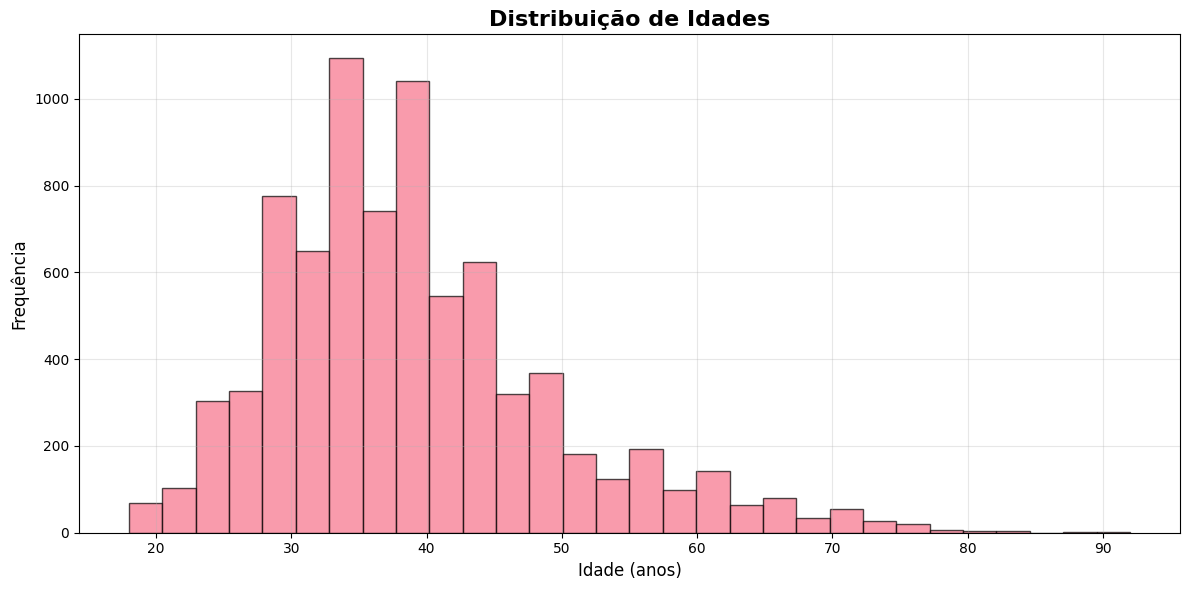

In [ ]:
# Configurar estilo
plt.style.use('default')  # ou 'seaborn' se tiver instalado
sns.set_palette("husl")

# Criar figura
plt.figure(figsize=(12, 6))

# Histograma básico
plt.hist(X_train['Age'].dropna(), bins=30, edgecolor='black', alpha=0.7)
plt.title('Distribuição de Idades', fontsize=16, fontweight='bold')
plt.xlabel('Idade (anos)', fontsize=12)
plt.ylabel('Frequência', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

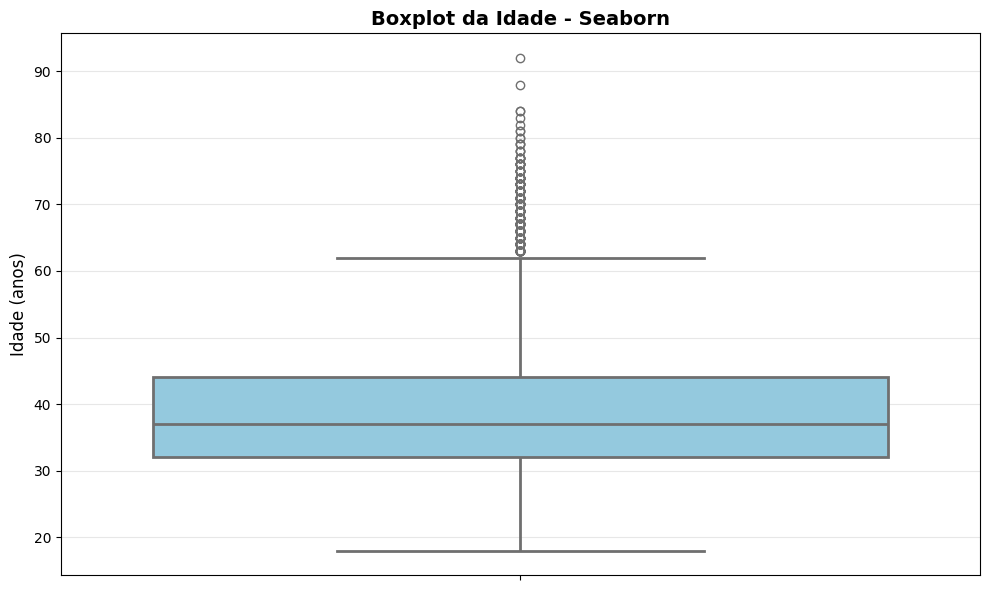

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(y=X_train['Age'], color='skyblue', linewidth=2)
plt.title('Boxplot da Idade - Seaborn', fontsize=14, fontweight='bold')
plt.ylabel('Idade (anos)', fontsize=12)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

**Nada de anormal nesta variável também**

## Ternure

In [ ]:
X_train['Tenure'].value_counts()

,count
Tenure,
2,844
1,825
7,823
8,822
3,819
5,816
6,783
4,781
9,768


**Nada de anormal nesta variável**

## Balance

In [ ]:
X_train['Balance'].describe()

,Balance
count,7996.000000
mean,76409.248410
std,62310.609851
min,0.000000
25%,0.000000
50%,97145.940000
75%,127477.692500
max,250898.090000


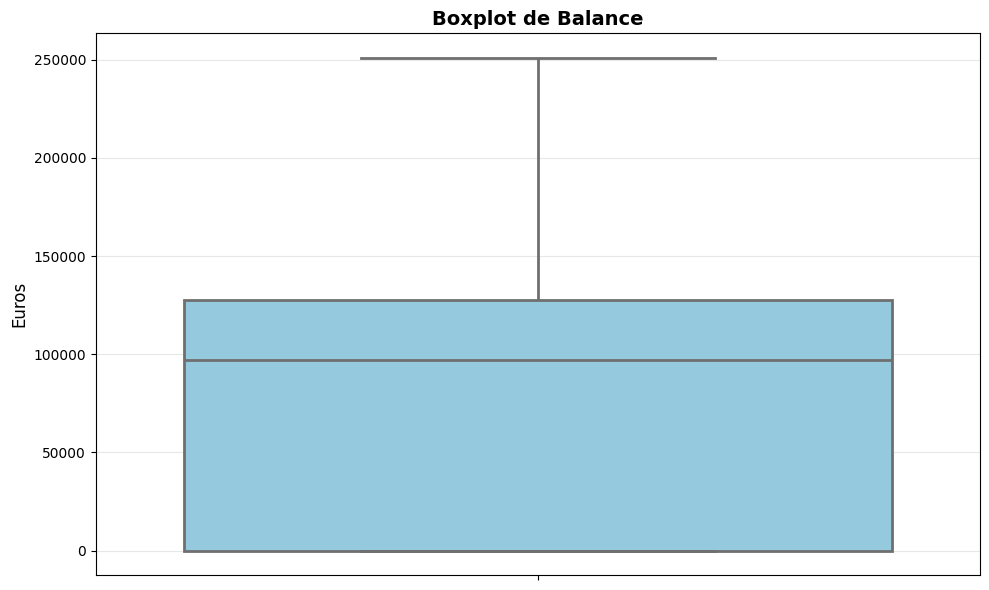

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(y=X_train['Balance'], color='skyblue', linewidth=2)
plt.title('Boxplot de Balance', fontsize=14, fontweight='bold')
plt.ylabel('Euros', fontsize=12)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

<Axes: >

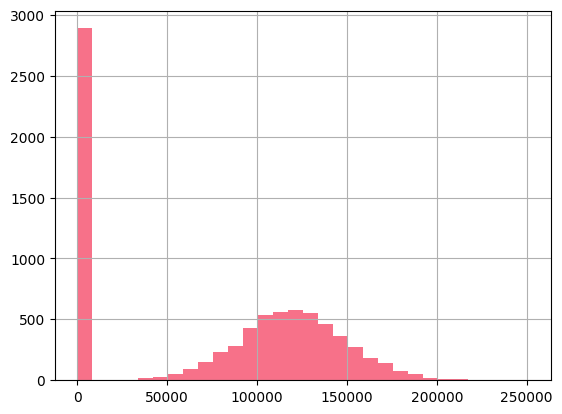

In [ ]:
# histograma para verificar melhor distribuição
X_train['Balance'].hist(bins=30)

**Nada de anormal nesta variável**

## NumOfProducts

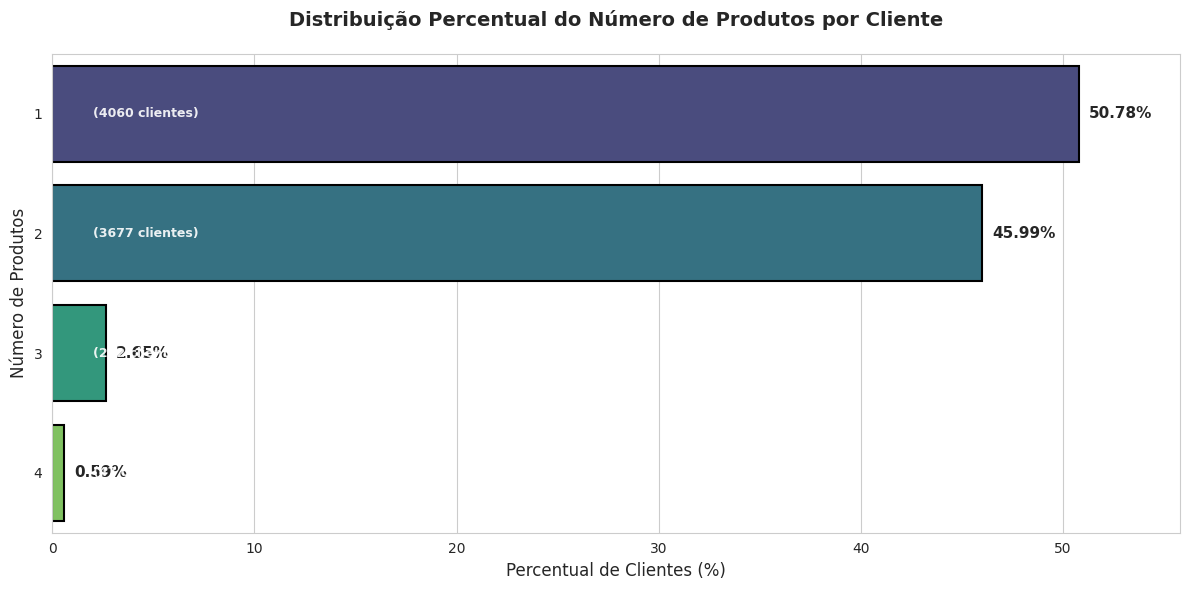

In [ ]:
# Calcular contagens e percentuais
product_counts = X_train['NumOfProducts'].value_counts().sort_index()
total = product_counts.sum()
percentuais = (product_counts / total * 100).round(2)

# Criar DataFrame para o seaborn
df_percent = pd.DataFrame({
    'Número de Produtos': product_counts.index.astype(str),
    'Percentual': percentuais.values,
    'Contagem': product_counts.values
})

# Configurar o estilo
sns.set_style("whitegrid")
plt.figure(figsize=(12, 6))

# Criar gráfico de barras horizontal com seaborn
ax = sns.barplot(data=df_percent, y='Número de Produtos', x='Percentual',
                 palette='viridis', edgecolor='black', linewidth=1.5)

# Adicionar os percentuais nas barras
for i, (_, row) in enumerate(df_percent.iterrows()):
    ax.text(row['Percentual'] + 0.5, i, f"{row['Percentual']}%",
            va='center', fontsize=11, fontweight='bold')

# Adicionar também as contagens absolutas em menor destaque
for i, (_, row) in enumerate(df_percent.iterrows()):
    ax.text(2, i, f"({row['Contagem']} clientes)",
            va='center', fontsize=9, color='white', alpha=0.9, fontweight='bold')

# Configurar título e labels
plt.title('Distribuição Percentual do Número de Produtos por Cliente',
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Percentual de Clientes (%)', fontsize=12)
plt.ylabel('Número de Produtos', fontsize=12)

# Ajustar limites do eixo x para dar espaço aos rótulos
plt.xlim(0, df_percent['Percentual'].max() + 5)

plt.tight_layout()
plt.show()

**Temos 2 classes subrepresentadas nessa variável que podem se tornar um problema para alguns modelos, porém iremos manter a variável por enquanto**

## HasCrCard

In [ ]:
X_train['HasCrCard'].value_counts()

,count
HasCrCard,
1.0,5633
0.0,2363


**Nada de anormal com essa variável**

## IsActiveMember

In [ ]:
X_train['IsActiveMember'].value_counts()

,count
IsActiveMember,
1.0,4118
0.0,3878


**Nada de anormal com essa variável**

## EstimatedSalary

In [ ]:
X_train['EstimatedSalary'].describe()

,EstimatedSalary
count,7996.000000
mean,100168.817032
std,57451.986989
min,11.580000
25%,51271.410000
50%,100127.245000
75%,149461.830000
max,199970.740000


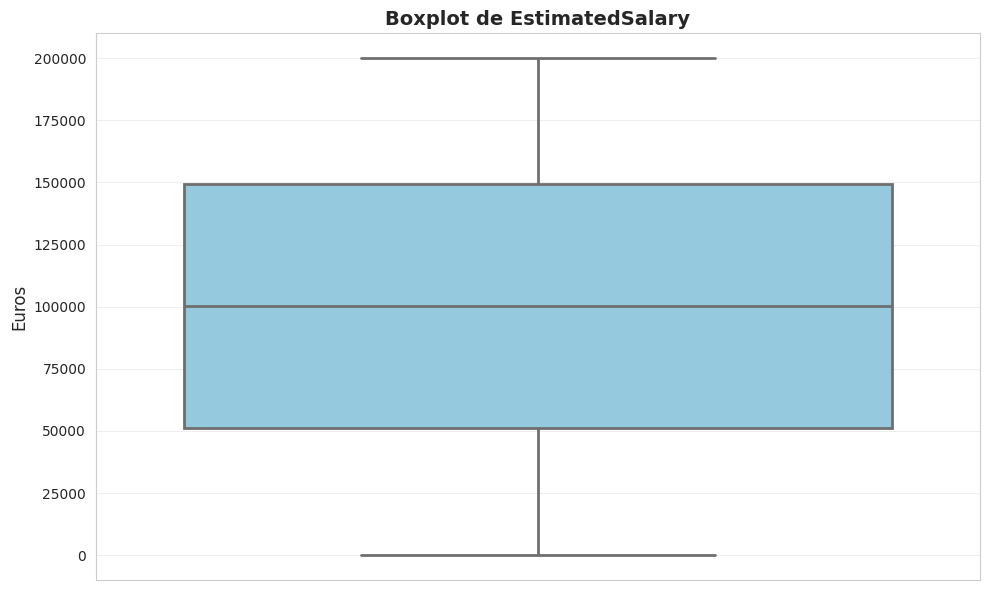

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(y=X_train['EstimatedSalary'], color='skyblue', linewidth=2)
plt.title('Boxplot de EstimatedSalary', fontsize=14, fontweight='bold')
plt.ylabel('Euros', fontsize=12)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

<Axes: >

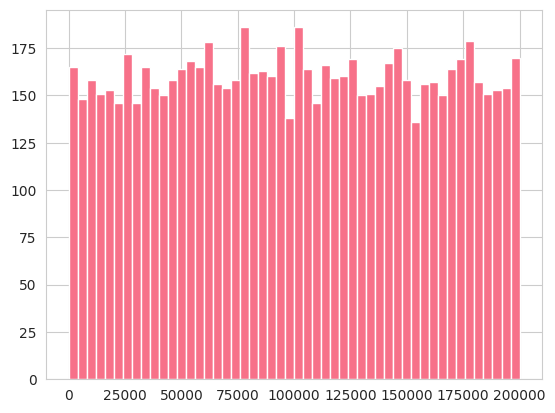

In [ ]:
X_train['EstimatedSalary'].hist(bins=50)

**Algumas estimativas de salários estão bem estranhas porém pelo menos por enquanto iremos manter essa variável**

## 2 - Pré - Processamento

*Faremos a Pipeline de Pré-processamento das variáveis, levando em considereção que estamos em um problema de classificação, desbalanceado e com o intuito de usar como Benchmark o modelo de REGRESSÃO LOGÍSTICA*

In [ ]:
X_train.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,cluster
2116,701,France,Male,44.0,7,0.00,2,1.0,0.0,23425.78,0
6526,574,France,Female,34.0,7,152992.91,1,1.0,1.0,134691.20,1
2016,696,France,Male,28.0,4,172646.82,1,1.0,1.0,116471.43,1
9820,648,Germany,Female,45.0,5,118886.55,1,0.0,0.0,51636.70,1
5421,589,France,Female,39.0,7,0.00,2,0.0,0.0,95985.64,0


In [ ]:
X_train.drop('cluster', axis=1, inplace=True)
X_test.drop('cluster', axis=1, inplace=True)

**Vamos fazer o enconding de variáveis categoricas, no nosso caso: Geography e Gender. Usaremos o One-hot enconding (k-1)**

In [ ]:

from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

numeric_features = [
    col for col in X_train.columns
    if X_train[col].dtype in ['int64', 'float64']
    and col not in ['Tenure', 'NumOfProducts', 'HasCrCard', 'IsActiveMember']
]
cat_features = ["Geography","Gender"]

preprocess = ColumnTransformer(
    transformers=[
        ("num", RobustScaler(), numeric_features),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_features),
    ],
    remainder="drop"
)


In [ ]:
# Aplicar transformação
X_train_array = preprocess.fit_transform(X_train)

# Obter nomes das colunas após transformação
# Features numéricas mantém os nomes originais
feature_names = numeric_features.copy()

# Adicionar nomes das features categóricas one-hot encoded
cat_encoder = preprocess.named_transformers_['cat']
cat_feature_names = cat_encoder.get_feature_names_out(cat_features)
feature_names.extend(cat_feature_names)

# Criar DataFrame
X_train_processed = pd.DataFrame(
    X_train_array,
    columns=feature_names,
    index=X_train.index  # manter o mesmo índice
)

In [ ]:

X_train_processed.head()

,CreditScore,Age,Balance,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
2116,0.374291,0.583333,-0.762062,-0.781150,0.0,0.0,1.0
6526,-0.586011,-0.250000,0.438092,0.352009,0.0,0.0,0.0
2016,0.336484,-0.750000,0.592267,0.166454,0.0,0.0,1.0
9820,-0.026465,0.666667,0.170544,-0.493842,1.0,0.0,0.0
5421,-0.472590,0.166667,-0.762062,-0.042179,0.0,0.0,0.0


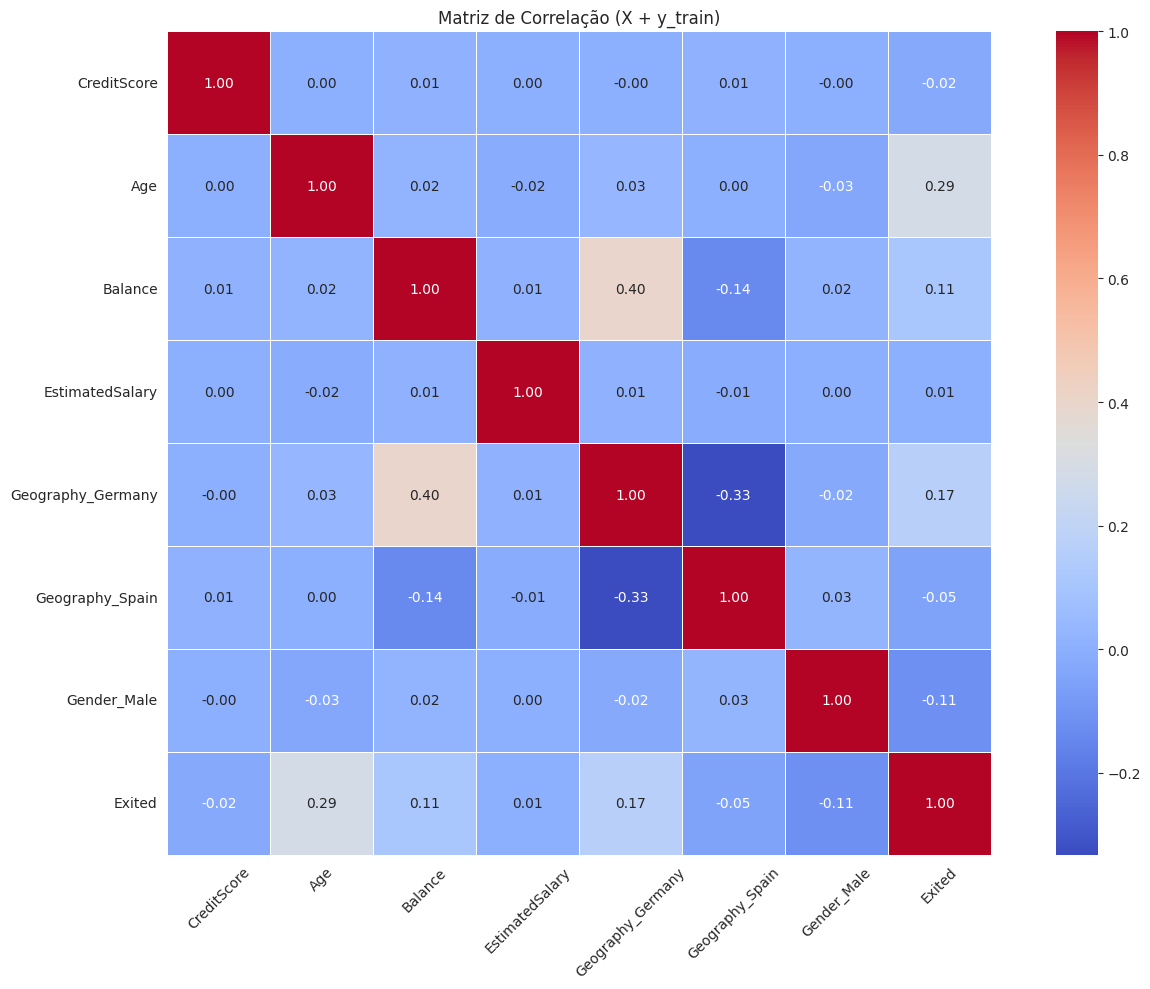

In [ ]:
# Garantir que y_train seja Series
if isinstance(y_train, pd.DataFrame):
    y_train_series = y_train.iloc[:, 0]
else:
    y_train_series = y_train

# Concatenar X e y
df_corr = pd.concat([X_train_processed, y_train_series], axis=1)

# Matriz de correlação
corr_matrix = df_corr.corr()

# Plot
plt.figure(figsize=(14,10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True
)

plt.title("Matriz de Correlação (X + y_train)")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# usando a pipeline em teste tambem
X_test_array = preprocess.transform(X_test)

## 3 - Modelagem

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

# Modelo
log_reg = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)
THRESHOLD = 0.3

# Treino
log_reg.fit(X_train_processed, y_train)

# Obter probabilidades (TREINO)
y_prob_train = log_reg.predict_proba(X_train_processed)[:, 1]

# Aplicar Threshold personalizado (TREINO)
y_pred_train_custom = (y_prob_train >= THRESHOLD).astype(int)

# Avaliação (TREINO)
print(f"Resultados com threshold(TREINO) = {THRESHOLD}")
print(classification_report(y_train, y_pred_train_custom))
print("ROC AUC:", roc_auc_score(y_train, y_prob_train))

# Obter probabilidades (TESTE)
y_prob = log_reg.predict_proba(X_test_array)[:, 1]

# Aplicar o threshold (TESTE)
y_pred_custom = (y_prob >= THRESHOLD).astype(int)

# Avaliação (TESTE)
print(f"Resultados com threshold(TESTE) = {THRESHOLD}")
print(classification_report(y_test, y_pred_custom))
print("ROC AUC:", roc_auc_score(y_test, y_prob))

Resultados com threshold(TREINO) = 0.3
              precision    recall  f1-score   support

           0       0.94      0.33      0.49      6358
           1       0.26      0.92      0.41      1638

    accuracy                           0.45      7996
   macro avg       0.60      0.63      0.45      7996
weighted avg       0.80      0.45      0.48      7996

ROC AUC: 0.7561234421096013
Resultados com threshold(TESTE) = 0.3
              precision    recall  f1-score   support

           0       0.95      0.34      0.50      1601
           1       0.26      0.93      0.41       399

    accuracy                           0.46      2000
   macro avg       0.61      0.64      0.46      2000
weighted avg       0.81      0.46      0.49      2000

ROC AUC: 0.7555146454518559


***Obtivemos um resultado bem satisfatório, pois com o Recall da classe 1 em 93% significa que o modelo está pegando quase todos os clientes que iriam sair, mesmo cometendo muitos falsos positivos (erro tipo I)***

***THRESHOLD: O modelo de Regressão Logística calcula a probabilidade de uma instância ser da classe 1(Churn), caso essa probabilidade seja maior que um Threshold, que por padrão é 50% o modelo classifica a instância como 1, ou seja Churn, caso contrario classifica como 0. Ao diminuirmos esse Threshold para 30% estamos dizendo para o modelo classificar como 1 todas as instâncias que tem probabilidade maior ou igual a 30% de serem dessa classe.***

**Class Weights="balanced" ->  Faz o ScikitLearn calcular automaticamente os pesos com base no balanceamento da variável target.**

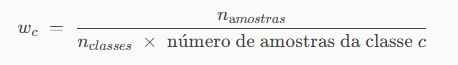

**Em nosso treino com 7996 registros, 6358 na classe 0 e 1638 na classe 1, os pesos para cada classe são: 0,628 para classe 0 e 2,440 para a classe 1**